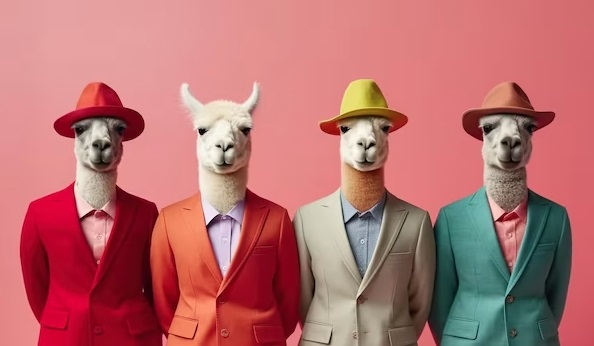

This project detects animals in photos, plus, automatically ignores any humans in the frame, and reimagines the isolated animal in a completely new scene based on a text prompt. In other words, turning a real photo of any animal into AI-generated art.

In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.6 MB/s eta 0:00:00


**Ultralytics** is a Python library developed by Ultralytics Inc. that provides the official implementation of the YOLOv8 (You Only Look Once) object detection architecture. YOLO is a real-time detection model that processes the entire image in a single forward pass through the neural network, making it significantly faster than traditional two-stage detectors.

In this project, Ultralytics is used to load a pretrained YOLOv8x model which is the largest and most accurate variant in the YOLOv8 family, and it was trained on the COCO dataset containing 80 object classes. The library handles everything from model loading and GPU acceleration to bounding box extraction and confidence scoring, allowing the project to detect and isolate animals from any uploaded photo with a single function call while automatically filtering out unwanted classes such as humans.

In [3]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, DPMSolverMultistepScheduler, AutoencoderKL
from diffusers.utils import load_image
from ultralytics import YOLO
import cv2
import gc, io, base64, os
import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display, HTML
import ipywidgets as widgets

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


- `torch` is the deep learning framework everything runs on, and handles GPU acceleration and tensor operations.
- `diffusers` imports bring in three things, they are: the main generation pipeline that combines the base image model with ControlNet, the ControlNet model itself which is responsible for preserving the animal's shape during generation, and the UniPC scheduler which controls how the image is built step by step during inference (it's faster and more stable than the default).
- `cv2` is OpenCV, used specifically for Canny edge detection, extracting the animal's structural outline from the crop.
- `numpy` handles the array operations between OpenCV and PIL.
- `PIL` is used for all image loading, resizing, and saving throughout the project.

In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32

print(f"Device: {DEVICE} / dtype: {DTYPE}")

Device: cuda / dtype: torch.float16


This block detects the available hardware and sets two global variables used throughout the entire project.

First of all, `DEVICE` checks whether a CUDA-capable GPU is available, and if yes it uses `'cuda'`, otherwise falls back to `'cpu'`.

Secon of all, `DTYPE` sets the numerical precision. It uses `float16` which cuts memory usage in half and runs significantly faster on modern GPUs with minimal quality loss, while on CPU it uses `float32`.

Eventually, every model and tensor operation in the project inherits these two variables, so changing hardware only requires updating this one cell.

In [5]:
COCO_ANIMALS = {14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow',
                20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe'}


# ControlNet v1.1
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_canny", torch_dtype = DTYPE, use_safetensors = True)

# Realistic Vision V5.1
sd_pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V5.1_noVAE", controlnet = controlnet, torch_dtype = DTYPE,
    safety_checker = None, requires_safety_checker = False, use_safetensors = True)

# VAE: sharper details and more accurate colors than built-in
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype = DTYPE)
sd_pipe.vae = vae

# UniPC scheduler: faster and better quality than default DDIM
sd_pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    sd_pipe.scheduler.config, algorithm_type = "dpmsolver++", use_karras_sigmas = True)
sd_pipe = sd_pipe.to(DEVICE)

# Memory optimizations
if DEVICE == 'cuda':
    sd_pipe.enable_attention_slicing(slice_size = "auto")
    sd_pipe.enable_vae_slicing()
    sd_pipe.enable_vae_tiling()

    try:
        sd_pipe.enable_xformers_memory_efficient_attention()
        print("xformers enabled!")
    except:
        sd_pipe.enable_attention_slicing(1)
        print("using torch native attention")

# Warm up it with a dummy one
with torch.no_grad():
    dummy_canny = Image.fromarray(np.zeros((512, 512, 3), dtype = np.uint8))
    _ = sd_pipe(prompt = "test", image = dummy_canny, num_inference_steps = 1, output_type = "latent")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2213: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


using torch native attention


  0%|          | 0/1 [00:00<?, ?it/s]

- **`COCO_ANIMALS`** is a dictionary mapping YOLO's numeric class IDs to their animal names. COCO labels every detected object with an integer ID (humans are class 0, vehicles are classes 1-8, and animals occupy IDs 14 through 23). By defining only these IDs in the dictionary, any detection whose class ID is not in this map gets silently ignored, which is exactly how humans are filtered out without any extra logic.

- **ControlNet** is loaded with the `control_v11p_sd15_canny` weights, and the v1.1 version specifically trained to accept Canny edge maps as structural guidance during image generation. `use_safetensors = True` loads weights in the safer and faster safetensors format instead of the older pickle-based format.

- **Realistic Vision V5.1** replaces the base Stable Diffusion 1.5 model as the generation backbone. It is a community fine-tuned checkpoint specifically optimized for photorealistic outputs, meaning animals look like real photographs rather than illustrations. The `noVAE` suffix means its built-in VAE decoder was intentionally left out so a better one can be plugged in separately.

- **VAE** is fine-tuned using mean squared error loss on high quality images, producing significantly sharper details and more accurate colors compared to the default VAE.

- **DPMSolver++ with Karras sigmas** replaces the default scheduler. It converges faster and more stably than the original DDIM scheduler, reaching equivalent quality in around 25–30 steps instead of 50, which cuts generation time nearly in half.

- **Memory optimizations** attention slicing breaks the attention computation into chunks to reduce peak VRAM usage, VAE slicing and tiling prevent out-of-memory crashes when decoding larger images, and xformers provides a highly optimized attention kernel that is both faster and more memory efficient than PyTorch's native implementation.

- Lastly, **the warm-up pass** runs a single dummy inference step at startup. This forces CUDA to compile all its kernels in advance so the very first real generation runs at full speed instead of suffering a 10–15 second compilation delay.

In [6]:
# Download dataset, and force model to GPU if available
detector = YOLO('yolov8x.pt')
detector.to(DEVICE)

# Warm up YOLO with another dummy image
dummy_img = np.zeros((640, 640, 3), dtype = np.uint8)
detector(dummy_img, verbose = False)
print("✅ Successfull!")

✅ Successfull!


This block loads the YOLOv8x model and prepares it for inference. `YOLO('yolov8x.pt')` automatically downloads the pretrained weights from Ultralytics servers if they are not already cached, thus, there is no manual download is needed. In addition, as we mentioned that the `x` variant is the largest and most accurate model in the YOLOv8 family, trained on the full COCO dataset.

Furthermore, `detector.to(DEVICE)` moves all model weights to the GPU so inference runs on CUDA rather than CPU, which is roughly 10-20x faster for detection.

Lastly, the warm-up pass creates a blank 640×640 black image and runs one silent inference through the model, this forces CUDA to compile the detection kernels in advance so the first real photo the user uploads gets processed at full speed instead of experiencing a noticeable delay.

In [7]:
# Color palette for bounding boxes
BOX_COLORS = ['#FF6B6B','#4ECDC4','#FFE66D','#A29BFE','#FD79A8','#00CEC9']

def draw_boxes(image: Image.Image, detections: list) -> Image.Image:
    vis     = image.copy().convert("RGBA")
    overlay = Image.new("RGBA", vis.size, (0,0,0,0))
    draw    = ImageDraw.Draw(overlay)

    for i, det in enumerate(detections):

        x1, y1, x2, y2 = det['box']
        label = det['label'].upper()
        conf  = det['conf']
        hex_c = BOX_COLORS[i % len(BOX_COLORS)]
        rgb   = tuple(int(hex_c[j : j + 2], 16) for j in (1, 3, 5))
        draw.rectangle([x1, y1, x2, y2], fill = (*rgb, 35), outline = (*rgb, 210), width = 3)
        badge_text = f"  {label} {conf:.0%}  "
        bw = len(badge_text) * 7
        draw.rounded_rectangle([x1, y1 - 26, x1 + bw, y1], radius = 6, fill = (*rgb, 220))
        draw.text((x1 + 4, y1 - 22), badge_text, fill = (255, 255, 255, 255))

    return Image.alpha_composite(vis, overlay).convert("RGB")


def detect_animals(image: Image.Image, conf_thresh = 0.35):
    results = detector(image, imgsz = 1280, verbose = False, augment = True, iou = 0.4)[0]
    detections = [ ]
    seen_boxes = [ ]

    for box in results.boxes:
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        if class_id not in COCO_ANIMALS or conf < conf_thresh: continue

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        # handles edge cases where TTA produces near-duplicate detections
        duplicate = False
        for sx1, sy1, sx2, sy2 in seen_boxes:
            inter_x = max(0, min(x2, sx2) - max(x1, sx1))
            inter_y = max(0, min(y2, sy2) - max(y1, sy1))
            inter = inter_x * inter_y
            area1 = (x2 - x1) * (y2 - y1)
            area2 = (sx2 - sx1) * (sy2 - sy1)
            iou = inter / (area1 + area2 - inter + 1e-6)

            if iou > 0.5:
                duplicate = True
                break

        if duplicate: continue
        seen_boxes.append((x1, y1, x2, y2))

        # tall animals (horse, giraffe) need more vertical padding
        # wide animals (cow, sheep) need more horizontal padding
        w, h  = x2 - x1, y2 - y1
        pad_x = int(w * 0.15)
        pad_y = int(h * 0.20)
        crop_box = (max(0, x1 - pad_x),
                    max(0, y1 - pad_y),
                    min(image.width,  x2 + pad_x),
                    min(image.height, y2 + pad_y))

        # small crops (< 80x80) produce bad generations, thus, flag them
        crop_w = crop_box[2] - crop_box[0]
        crop_h = crop_box[3] - crop_box[1]
        too_small = crop_w < 80 or crop_h < 80

        detections.append({
            'label' : COCO_ANIMALS[class_id],
            'conf' : conf,
            'box' : (x1, y1, x2, y2),
            'crop' : image.crop(crop_box),
            'too_small': too_small})

    # Sorted by confidence descending
    detections.sort(key = lambda d: d['conf'], reverse = True)
    annotated = draw_boxes(image, detections)
    return detections, annotated

print("✅ Successfull!")

✅ Successfull!


- **`BOX_COLORS`** is a palette of six distinct hex colors used to draw a different colored box around each detected animal, making it easy to visually distinguish multiple animals in the same photo.

- **`draw_boxes`** renders the detection results visually onto the image. It works on an RGBA overlay layer rather than directly on the original image, and this allows semi-transparent fills inside the bounding boxes without permanently modifying the original pixels. Each box gets a colored rectangle with a slight transparency fill, a solid colored outline, and a rounded badge above it showing the animal label and confidence score. The overlay is then composited onto the original image and converted back to RGB for display.

- **`detect_animals`** is the core detection function. It runs YOLOv8x at `imgsz = 1280`, so smaller or partially visible animals are caught more reliably. `augment = True` enables test-time augmentation, which runs detection on multiple flipped and scaled versions of the image and merges the results, reducing missed detections. `iou = 0.4` tightens the non-maximum suppression threshold to prevent duplicate boxes appearing around the same animal.

  The **duplicate filtering loop** manually computes the intersection-over-union between every new box and all previously accepted boxes. If overlap exceeds 50% the box is discarded, this catches any leftover duplicates that test-time augmentation occasionally produces.

  **Adaptive padding** adds 15% horizontal and 20% vertical padding around each detected box before cropping. The extra vertical margin specifically accounts for tall features like ears, horns, and the tops of heads that YOLO's tight bounding box often clips, which would otherwise cause the generation step to produce animals with missing body parts.

  The **`too_small` flag** marks any crop smaller than 80×80 pixels before it reaches the generation pipeline, and it means this does not contain enough structural detail for ControlNet to produce a meaningful edge map, so the UI warns the user rather than wasting generation time on a guaranteed poor result.

  Finally detections are **sorted by confidence descending** so the most confidently detected animal always appears first in the dropdown selector.

In [8]:
def extract_canny(image: Image.Image, low = 80, high = 200) -> Image.Image:

    img_np = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Normalizes uneven lighting across the animal (dark fur, bright background)
    clahe = cv2.createCLAHE(clipLimit = 2.0, tileGridSize = (8, 8))
    gray = clahe.apply(gray)

    # Gaussian blur removes noise but also softens real edges (fur outline, legs)
    # But bilateral filter removes noise while PRESERVING strong structural edges
    filtered = cv2.bilateralFilter(gray, d = 9, sigmaColor = 75, sigmaSpace = 75)

    # Otsu analyzes the image histogram and finds the optimal threshold automatically per image
    otsu_high, _ = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    otsu_low = otsu_high * 0.4 # low is always 40% of high (standard ratio)

    # Use Otsu thresholds but still allow manual override if passed explicitly
    final_low = low  if low != 80  else int(otsu_low)
    final_high = high if high != 200 else int(otsu_high)
    edges = cv2.Canny(filtered, final_low, final_high)

    # Broken edges (gaps in animal outline) confuse ControlNet about body boundaries
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    edges_3ch = np.stack([edges] * 3, axis = -1)
    return Image.fromarray(edges_3ch)

def prep_image(crop: Image.Image, size = 768) -> Image.Image:
    w, h = crop.size
    scale = size / max(w, h)
    nw, nh = int(w * scale), int(h * scale)

    # Aspect-ratio preserving resize + center pad (no stretching)
    # Stretching distorts animal proportions which hurts generation quality
    resized = crop.resize((nw, nh), Image.LANCZOS)
    canvas  = Image.new("RGB", (size, size), (127, 127, 127))
    canvas.paste(resized, ((size - nw) // 2, (size - nh) // 2))
    return canvas

def build_prompt(animal_name: str, user_prompt: str) -> tuple[str, str]:

    positive = (
        f"a single {animal_name}, {user_prompt}, "
        f"award winning wildlife photography, national geographic, "
        f"hyper realistic, ultra detailed fur texture, "
        f"professional DSLR, 8k resolution, sharp focus, "
        f"natural lighting, vivid colors, masterpiece")

    negative = (
        # Anatomy issues
        "deformed, bad anatomy, extra limbs, missing limbs, ""fused fingers, mutated, malformed, "
        # People
        "human, person, man, woman, child, crowd, "
        # Quality issues
        "blurry, low quality, low resolution, pixelated, ""watermark, text, logo, signature, "
        # Style issues
        "cartoon, anime, illustration, painting, drawing, ""ugly, disfigured, artifacts, noise")

    return positive, negative

def generate_reimagined(
    crop: Image.Image,
    animal_name: str,
    user_prompt: str,
    steps: int = 30,
    guidance: float = 8.5,
    canny_low: int = 80,
    canny_high: int = 200,
    controlnet_scale: float = 1.0,
    seed: int = -1
) -> tuple[Image.Image, Image.Image]:

    # Step 1: aspect-ratio preserving resize to 768x768
    init = prep_image(crop, size = 768)

    # Step 2: enhanced canny extraction
    canny_img = extract_canny(init, low = canny_low, high = canny_high)

    # Step 3: structured prompt
    full_prompt, negative = build_prompt(animal_name, user_prompt)
    print(f"Prompt: {full_prompt[:90]}...")

    # Using same seed across images makes results reproducible and comparable
    if seed == -1: seed = torch.randint(0, 2 ** 32, (1, )).item()
    generator = torch.Generator(device = DEVICE).manual_seed(seed)
    print(f"Seed: {seed}")

    with torch.autocast(DEVICE):
        result = sd_pipe(
            prompt = full_prompt, negative_prompt = negative,
            image = canny_img, num_inference_steps = steps,
            guidance_scale = guidance, controlnet_conditioning_scale = controlnet_scale,
            generator = generator, width = 768, height = 768).images[0]

    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return result, canny_img

print("✅ Successfull!")

✅ Successfull!


- **`extract_canny`** converts the animal crop into a structural edge map that ControlNet uses as a shape guide during generation. It applies 3 preprocessing steps before edge detection:
  - CLAHE (Contrast Limited Adaptive Histogram Equalization) normalizes uneven lighting across the image due to for the fact that without this, dark fur against a bright background produces inconsistent edges where some body parts are over-detected and others are missed entirely.
  - A bilateral filter removes noise while preserving strong structural edges like body outline and limb boundaries, unlike Gaussian blur which softens everything including real edges.
  - Otsu's method automatically analyzes the image histogram to find the optimal edge detection thresholds per image rather than using fixed values, so the same function works well on both a dark elephant and a light-colored sheep without manual tuning. *Morphological* closing then fills any small gaps in the detected outline, preventing ControlNet from misreading a broken body contour as separate disconnected shapes.

- **`prep_image`** resizes the animal crop to 768×768 while preserving the original aspect ratio. It scales the image so the longest side fits within 768 pixels, then centers it on a neutral gray canvas (gray is chosen over white or black because it introduces less color bias into the generation). Stretching to fill the square is deliberately avoided because distorted animal proportions confuse both the edge extraction and the generation model.

- **`build_prompt`** constructs the positive and negative prompts in a specific order because Stable Diffusion's attention mechanism weighs earlier tokens more heavily. The animal name and user scene description come first, followed by photography style keywords, then technical quality terms. The negative prompt is organized into four categories: anatomy issues, unwanted people, quality problems, and style mismatches, and each targeting a common failure mode in animal image generation.

- **`generate_reimagined`** ties the full pipeline together. It prepares the crop, extracts the edge map, builds the prompts, sets a deterministic seed for reproducibility, then passes everything to the ControlNet pipeline at 768×768 resolution.

  After generation it immediately frees GPU memory with `gc.collect()` and `empty_cache()` to prevent out-of-memory errors when generating multiple images in sequence. It returns both the generated image and the canny edge map so the user can inspect exactly what structural information ControlNet was given.

In [12]:
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Bebas+Neue&family=Rajdhani:wght@400;500;600;700&family=Share+Tech+Mono:wght@400;700&display=swap');
* { box-sizing: border-box; }

:root {
  --bg:       #07090d;
  --surface:  #0c0f15;
  --surface2: #10141c;
  --border:   #1c2535;
  --border2:  #243040;
  --gold:     #c9a84c;
  --gold2:    #e8c96a;
  --golddim:  #7a6030;
  --cyan:     #4fc3f7;
  --text:     #c8d4e0;
  --muted:    #3d5166;
  --mono:     'Share Tech Mono', monospace;
}

.gm-wrap {
  font-family: 'Rajdhani', sans-serif;
  color: var(--text);
  max-width: 960px;
  background: var(--bg);
  padding: 4px;
}

.gm-hero {
  position: relative;
  background: linear-gradient(160deg, #07090d 0%, #0b1120 45%, #07090d 100%);
  border: 1px solid var(--border2);
  border-top: 3px solid var(--gold);
  border-radius: 2px;
  padding: 44px 52px 38px;
  margin-bottom: 18px;
  overflow: hidden;
}
.gm-hero-grid {
  position: absolute; inset: 0;
  background-image:
    linear-gradient(rgba(28,37,53,.5) 1px, transparent 1px),
    linear-gradient(90deg, rgba(28,37,53,.5) 1px, transparent 1px);
  background-size: 48px 48px;
  pointer-events: none;
}
.gm-hero-glow-r {
  position: absolute; top: -100px; right: -100px;
  width: 500px; height: 500px;
  background: radial-gradient(circle, rgba(201,168,76,.08) 0%, transparent 60%);
  pointer-events: none;
}
.gm-hero-glow-l {
  position: absolute; bottom: -80px; left: -60px;
  width: 360px; height: 360px;
  background: radial-gradient(circle, rgba(79,195,247,.04) 0%, transparent 60%);
  pointer-events: none;
}
.gm-bat-bg {
  position: absolute; right: 40px; bottom: -20px;
  font-size: 9rem; opacity: .035;
  transform: scaleX(1.4); line-height: 1;
  pointer-events: none; user-select: none;
}
.gm-eyebrow {
  font-family: var(--mono); font-size: .62rem;
  color: var(--golddim); letter-spacing: .35em;
  text-transform: uppercase; margin: 0 0 12px;
  display: flex; align-items: center; gap: 12px;
}
.gm-eyebrow::before {
  content: ''; width: 32px; height: 1px;
  background: linear-gradient(90deg, transparent, var(--golddim));
}
.gm-eyebrow::after {
  content: ''; flex: 1; height: 1px;
  background: linear-gradient(90deg, var(--golddim), transparent);
}
.gm-title {
  font-family: 'Bebas Neue', sans-serif;
  font-size: 4.2rem; letter-spacing: .08em;
  margin: 0 0 6px; line-height: 1;
  background: linear-gradient(175deg, #f0d878 0%, #c9a84c 40%, #7a5c1e 100%);
  -webkit-background-clip: text; -webkit-text-fill-color: transparent;
  filter: drop-shadow(0 0 30px rgba(201,168,76,.28));
}
.gm-sub {
  color: var(--muted); font-size: .83rem;
  margin: 0; font-family: var(--mono); letter-spacing: .05em;
}
.gm-tags { margin-bottom: 18px; display: flex; gap: 8px; flex-wrap: wrap; }
.gm-tag {
  display: inline-flex; align-items: center; gap: 6px;
  border: 1px solid #1c2535; color: #3d5166;
  background: rgba(12,15,21,.8);
  border-radius: 2px; font-family: var(--mono);
  font-size: .62rem; padding: 3px 11px;
  letter-spacing: .1em; text-transform: uppercase;
  transition: border-color .2s, color .2s;
}
.gm-tag:hover { border-color: var(--golddim); color: var(--gold); }
.gm-tag::before { content: '▸'; color: var(--golddim); font-size: .5rem; }

.gm-panel {
  background: var(--surface);
  border: 1px solid var(--border);
  border-left: 2px solid var(--gold);
  border-radius: 2px;
  padding: 22px 28px 26px;
  margin-bottom: 14px;
  position: relative; overflow: hidden;
}
.gm-panel::after {
  content: '';
  position: absolute; top: 0; right: 0;
  width: 80px; height: 80px;
  background: linear-gradient(225deg, rgba(201,168,76,.04) 0%, transparent 65%);
  pointer-events: none;
}
.gm-panel-title {
  font-family: var(--mono); font-size: .66rem;
  color: var(--muted); text-transform: uppercase;
  letter-spacing: .22em; margin: 0 0 20px;
  display: flex; align-items: center; gap: 12px;
}
.gm-panel-num {
  font-family: 'Bebas Neue', sans-serif;
  font-size: 1.5rem; color: var(--gold);
  opacity: .65; line-height: 1;
}
.gm-panel-title::after {
  content: ''; flex: 1; height: 1px;
  background: linear-gradient(90deg, var(--border2), transparent);
}

.gm-status {
  font-family: var(--mono); font-size: .77rem; color: var(--cyan);
  background: rgba(79,195,247,.04);
  border-left: 2px solid var(--cyan);
  padding: 11px 16px; border-radius: 2px;
  margin: 12px 0; line-height: 1.75;
}
.gm-status::before { content: '›› '; opacity: .45; }
.gm-warn  { color: var(--gold2)!important; border-left-color: var(--gold2)!important; background: rgba(201,168,76,.04)!important; }
.gm-error { color: #e05555!important; border-left-color: #e05555!important; background: rgba(224,85,85,.04)!important; }

.gm-gallery { display: flex; flex-wrap: wrap; gap: 14px; margin-top: 14px; }
.gm-card {
  background: var(--bg);
  border: 1px solid var(--border);
  border-radius: 2px; overflow: hidden;
  position: relative;
  transition: border-color .25s, transform .25s, box-shadow .25s;
}
.gm-card::before {
  content: '';
  position: absolute; top: 0; left: 0; right: 0;
  height: 2px;
  background: linear-gradient(90deg, var(--gold), var(--golddim), transparent);
  opacity: 0; transition: opacity .25s;
}
.gm-card:hover { border-color: var(--golddim); transform: translateY(-4px); box-shadow: 0 12px 40px rgba(201,168,76,.1); }
.gm-card:hover::before { opacity: 1; }
.gm-card img { display: block; }
.gm-cap {
  font-family: var(--mono); font-size: .64rem; color: var(--muted);
  padding: 8px 12px; border-top: 1px solid var(--border);
  letter-spacing: .06em; text-transform: uppercase;
}

.gm-divider {
  border: none; border-top: 1px solid var(--border);
  margin: 18px 0; position: relative;
}
.gm-divider::after {
  content: '◆'; position: absolute;
  left: 50%; top: -7px; transform: translateX(-50%);
  color: var(--golddim); font-size: .5rem;
  background: var(--surface); padding: 0 10px;
}

.gm-badge {
  display: inline-block;
  background: rgba(201,168,76,.08);
  color: var(--gold); border: 1px solid rgba(201,168,76,.25);
  border-radius: 2px; font-family: var(--mono);
  font-size: .6rem; padding: 1px 7px; margin-left: 6px;
  letter-spacing: .06em; text-transform: uppercase;
}
</style>

<div class='gm-wrap'>
  <div class='gm-hero'>
    <div class='gm-hero-grid'></div>
    <div class='gm-hero-glow-r'></div>
    <div class='gm-hero-glow-l'></div>
    <div class='gm-bat-bg'>🗿</div>
    <div class='gm-eyebrow'>Arkham Intelligence Division &nbsp;·&nbsp; Fauna Reconnaissance Unit</div>
    <div class='gm-tags'>
      <span class='gm-tag'>YOLOv8x</span>
      <span class='gm-tag'>ControlNet v1.1</span>
      <span class='gm-tag'>Realistic Vision V5</span>
      <span class='gm-tag'>COCO Dataset</span>
    </div>
    <h1 class='gm-title'>GargoylEye</h1>
    <p class='gm-sub'>// upload any photo → animals detected, humans ignored → reimagine them anywhere</p>
  </div>
</div>
"""))

# - SECTION 01 -
display(HTML("""
<div class='gm-panel'>
  <p class='gm-panel-title'>
    <span class='gm-panel-num'>01</span>
    Target Acquisition &amp; Detection
  </p>
</div>
"""))

upload = widgets.FileUpload(
    accept = '.jpg,.jpeg,.png,.webp', multiple = False,
    description = '📂 Upload Image', layout=widgets.Layout(width = '220px'))

conf_slider = widgets.FloatSlider(
    value=0.35, min=0.10, max=0.90, step=0.05,
    description='Confidence:', style={'description_width':'100px'},
    layout=widgets.Layout(width='400px'),
)
detect_btn = widgets.Button(
    description='🔍  Run Detection',
    layout=widgets.Layout(width='200px', height='40px'),
    style={'button_color':'#0e1420'},
)
detect_out = widgets.Output()

display(widgets.VBox([
    widgets.HBox([upload, detect_btn]),
    widgets.HTML("<p style='color:#3d5166;font-size:.7rem;font-family:Share Tech Mono,monospace;margin:8px 0 4px;letter-spacing:.08em;'>// CONFIDENCE THRESHOLD — lower catches more targets, higher is stricter</p>"),
    conf_slider,
    detect_out
]))

# - SECTION 02 -
display(HTML("""
<div class='gm-panel' style='margin-top:6px;'>
  <p class='gm-panel-title'>
    <span class='gm-panel-num'>02</span>
    Select Target &amp; Define Mission
  </p>
</div>
"""))

animal_dd = widgets.Dropdown(
    options=['Run detection first'],
    description='🐾 Target:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='100%')
)

PRESETS = {
    '🎓 Student'  : 'wearing a graduation cap, sitting in a cozy classroom, books and chalkboard',
    '🚀 Astronaut': 'wearing a NASA spacesuit, floating in space, Earth in background, stars',
    '🏙️ Cyberpunk': 'in a neon-lit cyberpunk city at night, rain reflections, holographic signs',
    '🌊 Ocean'    : 'swimming in a crystal-clear tropical ocean, colourful coral reef, sunbeams',
    '🦇 Gotham'   : 'standing on a Gotham City rooftop at night, fog, city lights below, dramatic dark sky',
}

prompt_box = widgets.Textarea(
    value=list(PRESETS.values())[0],
    description='✏️ Prompt:',
    rows = 3,
    style={'description_width':'70px'},
    layout=widgets.Layout(width='80%')
)

preset_btns = []
for label, text in PRESETS.items():
    b = widgets.Button(description=label, layout=widgets.Layout(width='158px', height='34px'))
    b.style.button_color = '#0c0f15'
    b.on_click(lambda evt, t=text: setattr(prompt_box, 'value', t))
    preset_btns.append(b)

display(widgets.VBox([
    animal_dd,
    widgets.HTML("<p style='color:#3d5166;font-size:.7rem;font-family:Share Tech Mono,monospace;margin:12px 0 7px;letter-spacing:.08em;'>// MISSION PRESETS</p>"),
    widgets.HBox(preset_btns[:5]),
    widgets.HBox(preset_btns[5:]),
    widgets.HTML("<div style='height:10px'></div>"),
    prompt_box
]))

# - SECTION 03 -
display(HTML("""
<div class='gm-panel' style='margin-top:6px;'>
  <p class='gm-panel-title'>
    <span class='gm-panel-num'>03</span>
    Execute Generation
  </p>
</div>
"""))

n_images = widgets.IntSlider(
    value=2, min=1, max=4, step=1,
    description='🖼️  # Images:',
    style={'description_width':'130px'},
    layout=widgets.Layout(width='380px')
)


gen_btn = widgets.Button(
    description='✦  Generate Now',
    layout=widgets.Layout(width='230px', height='48px'),
    style={'button_color':'#120a04'},
)
gen_out = widgets.Output()

display(widgets.VBox([
    n_images,
    widgets.HTML("<div style='height:8px'></div>"),
    gen_btn,
    gen_out,
]))

# - SHARED STATE -
state = {'detections': [], 'source': None}

# - DETECTION CALLBACK -
def on_detect(b):
    detect_out.clear_output()
    with detect_out:
        if not upload.value:
            display(HTML("<p class='gm-status gm-warn'>⚠ No image uploaded. Awaiting target acquisition.</p>"))
            return

        display(HTML("<p class='gm-status'>⏳ Scanning with YOLOv8x at 1280px resolution…</p>"))

        raw   = list(upload.value.values())[0]
        data  = raw['content'] if isinstance(raw['content'], bytes) else bytes(raw['content'])
        image = Image.open(io.BytesIO(data)).convert("RGB")
        state['source'] = image

        detections, annotated = detect_animals(image, conf_thresh = conf_slider.value)
        state['detections'] = detections

        if not detections:
            display(HTML("<p class='gm-status gm-warn'>⚠ No targets acquired. Lower confidence or use a clearer image.</p>"))
            buf = io.BytesIO(); image.save(buf, "PNG")
            b64 = base64.b64encode(buf.getvalue()).decode()
            display(HTML(f"<div class='gm-card'><img src='data:image/png;base64,{b64}' style='width:520px;'><div class='gm-cap'>Original — no targets detected</div></div>"))
            return

        animal_dd.options = [
            f"#{i+1}  {d['label'].upper()}  ({d['conf']:.0%})" for i, d in enumerate(detections)
        ]
        animal_dd.value = animal_dd.options[0]

        buf = io.BytesIO(); annotated.save(buf, "PNG")
        ann_b64 = base64.b64encode(buf.getvalue()).decode()

        crop_cards = ""
        for i, d in enumerate(detections):
            buf2 = io.BytesIO(); d['crop'].save(buf2, "PNG")
            c64  = base64.b64encode(buf2.getvalue()).decode()
            warn = "<span class='gm-badge'>⚠ small</span>" if d.get('too_small') else ""
            crop_cards += f"""
            <div class='gm-card'>
              <img src='data:image/png;base64,{c64}' style='width:200px;'>
              <div class='gm-cap'>#{i + 1} {d['label']} · {d['conf']:.0%}{warn}</div>
            </div>"""

        found = "  ·  ".join(f"{d['label']} {d['conf']:.0%}" for d in detections)
        display(HTML(f"""
        <p class='gm-status'>Target lock: <strong>{len(detections)}</strong> animal(s) acquired — {found} — humans suppressed</p>
        <div class='gm-gallery'>
          <div class='gm-card'>
            <img src='data:image/png;base64,{ann_b64}' style = 'width:560px;'>
            <div class='gm-cap'>Detection sweep — annotated result</div>
          </div>
        </div>
        <p style='color:#3d5166;font-size:.68rem;font-family:Share Tech Mono,monospace;margin:14px 0 6px;letter-spacing:.08em;'>// ISOLATED TARGETS</p>
        <div class='gm-gallery'>{crop_cards}</div>
        """))

detect_btn.on_click(on_detect)

# - GENERATION CALLBACK -
def on_generate(b):
    gen_out.clear_output()
    with gen_out:
        if not state['detections']:
            display(HTML("<p class='gm-status gm-warn'>⚠ Run detection first.</p>"))
            return
        if not prompt_box.value.strip():
            display(HTML("<p class='gm-status gm-warn'>⚠ No mission prompt entered.</p>"))
            return

        idx  = animal_dd.index if animal_dd.index is not None else 0
        det  = state['detections'][idx]
        name = det['label']
        crop = det['crop']

        if det.get('too_small'):
            display(HTML("<p class='gm-status gm-warn'>⚠ Crop resolution low — output quality may be reduced.</p>"))

        n = n_images.value
        display(HTML(f"<p class='gm-status'>🎨 Initiating generation sequence — <strong>{n}</strong> render(s) of <strong>{name}</strong>… ~15–30s each on T4</p>"))

        results, canny_ref = [], None

        for i in range(n):
            print(f"  Rendering {i+1}/{n}...")
            gen_img, canny_img = generate_reimagined(
                crop = crop, animal_name = name, user_prompt = prompt_box.value.strip(),
                steps = 30, guidance = 8.5, canny_low = 80, canny_high = 200,
                controlnet_scale = 1.0, seed = i * 77)
            results.append(gen_img)
            if i == 0: canny_ref = canny_img

        def to_b64(img):
            buf = io.BytesIO(); img.save(buf, "PNG")
            return base64.b64encode(buf.getvalue()).decode()

        crop_disp  = prep_image(crop, size=560)
        canny_disp = canny_ref.resize((560, 560), Image.LANCZOS)

        ref_row = f"""
        <div class='gm-card'>
          <img src='data:image/png;base64,{to_b64(crop_disp)}' style='width:560px;'>
          <div class='gm-cap'>📷 original crop — {name}</div>
        </div>
        <div class='gm-card'>
          <img src='data:image/png;base64,{to_b64(canny_disp)}' style='width:560px;'>
          <div class='gm-cap'>🔲 structural edge map</div>
        </div>"""

        gen_row = ""
        for j, res in enumerate(results):
            res_large = res.resize((560, 560), Image.LANCZOS)
            gen_row += f"""
            <div class='gm-card'>
              <img src='data:image/png;base64,{to_b64(res_large)}' style='width:560px;'>
              <div class='gm-cap'>✦ generated render #{j + 1}</div>
            </div>"""

        display(HTML(f"""
        <p class='gm-status'>Mission complete — prompt: <em>"{prompt_box.value[:72]}…"</em></p>
        <p style='color:#3d5166;font-size:.68rem;font-family:Share Tech Mono,monospace;margin:14px 0 6px;letter-spacing:.08em;'>// INPUT REFERENCE</p>
        <div class='gm-gallery'>{ref_row}</div>
        <div class='gm-divider'></div>
        <p style='color:#3d5166;font-size:.68rem;font-family:Share Tech Mono,monospace;margin:14px 0 6px;letter-spacing:.08em;'>// GENERATED OUTPUT</p>
        <div class='gm-gallery'>{gen_row}</div>
        """))

        os.makedirs('/content/output', exist_ok = True)
        for j, res in enumerate(results):
            res.save(f'/content/output/{name}_gen{j + 1}.png')

gen_btn.on_click(on_generate)

Basically, this block builds the complete interactive user interface for the GargoylEye system using ipywidgets and custom HTML/CSS rendered directly inside the Colab notebook.

- **Section 01 - Target Acquisition**: a file upload widget accepts JPG, PNG and WEBP images. A confidence threshold slider lets the user control how strict the YOLO detection is before accepting a result. The "Run Detection" button triggers the `on_detect` callback function defined later in the same cell.

- **Section 02 - Mission Definition**: a dropdown gets populated automatically after detection runs, listing every detected animal with its confidence score. Below it, five preset scene buttons act as one-click prompt templates, clicking any of them calls `setattr` to instantly overwrite the text area value. The free-text prompt area allows the user to write any custom scene description beyond the presets.

- **Section 03 - Execute Generation**: a single slider controls how many images to generate per run (1 to 4). The generate button triggers `on_generate`.

- **Shared State**: the `state` dictionary acts as a simple in-memory store that passes data between the two callbacks. `state['detections']` holds the list of detected animals and their crops so the generation callback can access them without re-running detection.

- **Detection Callback (`on_detect`)**: reads the raw bytes from the uploaded file, converts them to a PIL image, and passes it to `detect_animals`. If no animals are found it shows a warning. If animals are found it updates the dropdown options, displays the annotated image at 560px width, and shows each individual animal crop with a small warning badge if the crop is too small for quality generation.

- **Generation Callback (`on_generate`)**: validates that detection has been run and a prompt exists. It then loops through the requested number of images, calling `generate_reimagined` for each one with fixed optimal parameters. After all renders complete it displays two rows — the first showing the original crop and its structural edge map side by side as input reference, the second showing all generated outputs. Every result is automatically saved to `/content/output/` with the animal name and render number in the filename.

In [ ]:
# Finally

***I WOULD LIKE TO EXPRESS MY SINCERE GRATITUDE FOR YOUR TIME AND CONSIDERATION***

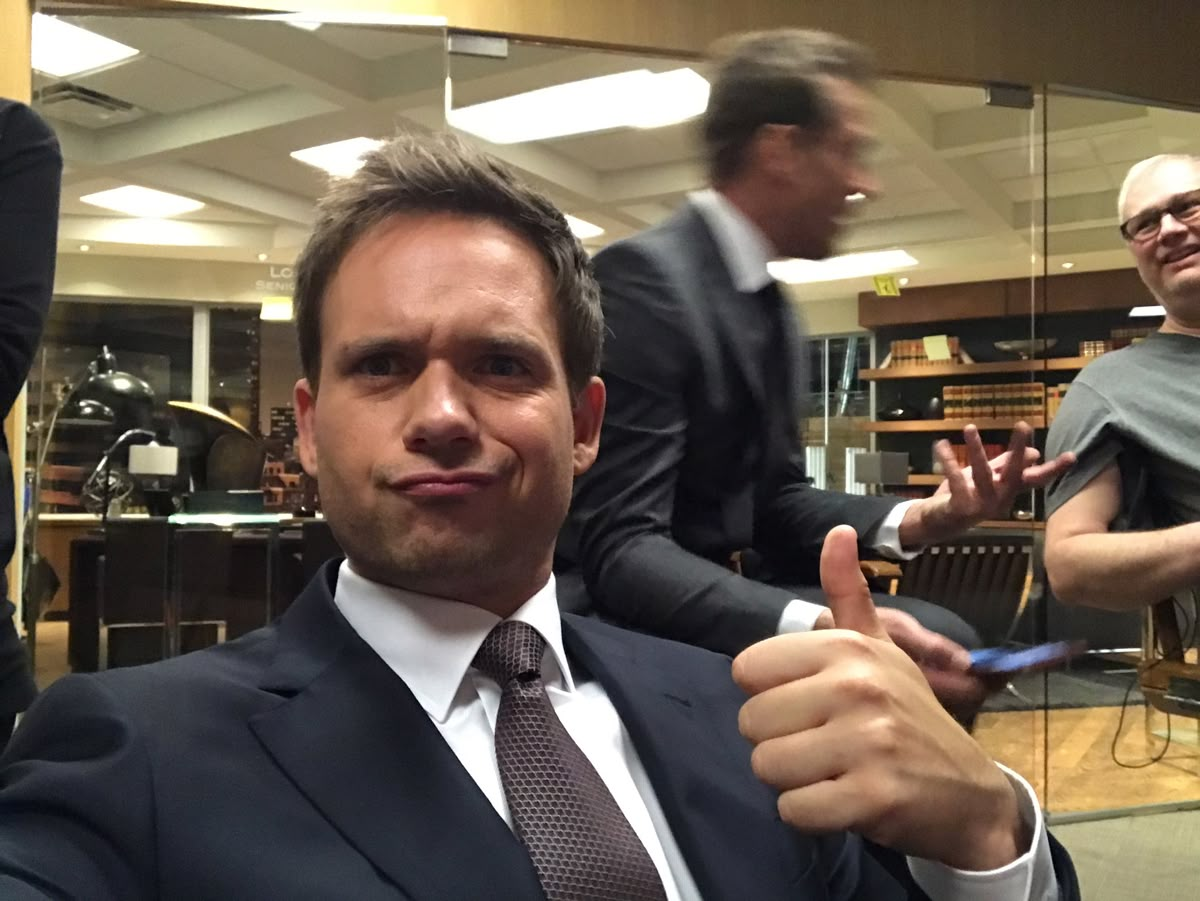